 • Acesse o link: https://data.who.int/countries/076

 • Escolha 3 datasets distintos. Alguns exemplos interessantes incluem:

 • Estastísticas sobre saúde pública

 • Gastos públicos com saúde pública

 • Natalidade e mortalidade



 • Para cada dataset selecionado, realize uma análise exploratória visual,
 respondendo perguntas
 como:

 • Como esses indicadores evoluíram ao longo do tempo?

 • Existem padrões regionais ou demográficos?

 • Algum indicador parece estar relacionado com outro?




 • Escolha uma biblioteca de visualização interativa para implementar sua análise:

 • Plotly

 • Dash

 • Bokeh

 • D3.js

### **O consumo de Alcool de acordo com os sexos e a projecão para 2030**
Dataset Alcohol

In [1]:
#bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

**Dicionário do CSV Alcohol**



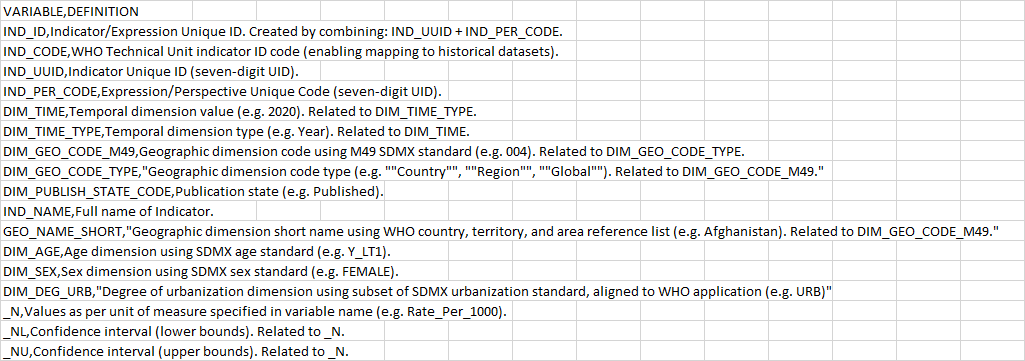

**Lista de códigos**

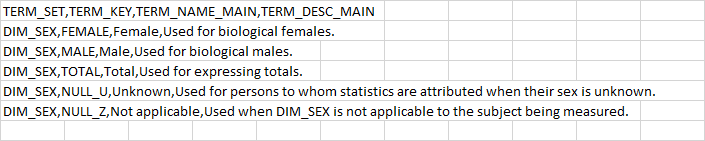

In [2]:
df = pd.read_csv('/content/076_EE6F72A_Dataset_2024-06-21.csv', sep=',')
df.head()

,IND_UUID,IND_NAME,DIM_GEO_CODE_TYPE,DIM_GEO_CODE_M49,GEO_NAME_SHORT,DIM_TIME_TYPE,DIM_TIME,Sex,RATE_PER_CAPITA_N,RATE_PER_CAPITA_NL,RATE_PER_CAPITA_NU
0,EE6F72A,Alcohol consumption (age 15+),COUNTRY,76,Brazil,YEAR,2003,Female,3.641691,2.378560,4.980352
1,EE6F72A,Alcohol consumption (age 15+),COUNTRY,76,Brazil,YEAR,2004,Female,3.604616,2.385173,4.938590
2,EE6F72A,Alcohol consumption (age 15+),COUNTRY,76,Brazil,YEAR,2010,Female,3.741420,2.479705,5.062658
3,EE6F72A,Alcohol consumption (age 15+),COUNTRY,76,Brazil,YEAR,2012,Female,3.700590,2.519308,5.048486
4,EE6F72A,Alcohol consumption (age 15+),COUNTRY,76,Brazil,YEAR,2014,Female,3.576964,2.386672,4.884757


In [3]:
#Verificar se os valores são nulos
df.isnull().sum()

,0
IND_UUID,0
IND_NAME,0
DIM_GEO_CODE_TYPE,0
DIM_GEO_CODE_M49,0
GEO_NAME_SHORT,0
DIM_TIME_TYPE,0
DIM_TIME,0
Sex,0
RATE_PER_CAPITA_N,0
RATE_PER_CAPITA_NL,0


In [4]:
#Verificar as informações do CSV
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   IND_UUID            32 non-null     object 
 1   IND_NAME            32 non-null     object 
 2   DIM_GEO_CODE_TYPE   32 non-null     object 
 3   DIM_GEO_CODE_M49    32 non-null     int64  
 4   GEO_NAME_SHORT      32 non-null     object 
 5   DIM_TIME_TYPE       32 non-null     object 
 6   DIM_TIME            32 non-null     int64  
 7   Sex                 32 non-null     object 
 8   RATE_PER_CAPITA_N   32 non-null     float64
 9   RATE_PER_CAPITA_NL  32 non-null     float64
 10  RATE_PER_CAPITA_NU  32 non-null     float64
dtypes: float64(3), int64(2), object(6)
memory usage: 2.9+ KB


In [5]:
#Verifica os tipos de dados de cada coluna
df.dtypes

,0
IND_UUID,object
IND_NAME,object
DIM_GEO_CODE_TYPE,object
DIM_GEO_CODE_M49,int64
GEO_NAME_SHORT,object
DIM_TIME_TYPE,object
DIM_TIME,int64
Sex,object
RATE_PER_CAPITA_N,float64
RATE_PER_CAPITA_NL,float64


In [6]:
# Excluindo as colunas desnecessárias IND_UUID até DIM_TIME_TYPE
df = df.drop(columns=['IND_UUID','IND_NAME', 'DIM_GEO_CODE_TYPE', 'DIM_GEO_CODE_M49', 'GEO_NAME_SHORT', 'DIM_TIME_TYPE'])
df.head()

,DIM_TIME,Sex,RATE_PER_CAPITA_N,RATE_PER_CAPITA_NL,RATE_PER_CAPITA_NU
0,2003,Female,3.641691,2.378560,4.980352
1,2004,Female,3.604616,2.385173,4.938590
2,2010,Female,3.741420,2.479705,5.062658
3,2012,Female,3.700590,2.519308,5.048486
4,2014,Female,3.576964,2.386672,4.884757


In [7]:
#Transformar a coluna Sexo em números binarios
df['Sex'] = df['Sex'].map({'Female': 0, 'Male': 1})
df.head()

,DIM_TIME,Sex,RATE_PER_CAPITA_N,RATE_PER_CAPITA_NL,RATE_PER_CAPITA_NU
0,2003,0,3.641691,2.378560,4.980352
1,2004,0,3.604616,2.385173,4.938590
2,2010,0,3.741420,2.479705,5.062658
3,2012,0,3.700590,2.519308,5.048486
4,2014,0,3.576964,2.386672,4.884757


In [8]:
# Mapeando Sex para M e F (assumindo Sex 0 = F, Sex 1 = M)
df['Sex'] = df['Sex'].map({0: 'F', 1: 'M'})

# Ordenando por DIM_TIME para garantir consistência
df = df.sort_values(['Sex', 'DIM_TIME'])

# Criando projeções futuras (2021-2030)
future_years = np.arange(2021, 2031)
projections = []

# Ajustando modelo de regressão linear para cada sexo
for sex in df['Sex'].unique():
    df_sex = df[df['Sex'] == sex]

    # Preparando dados para regressão
    X = df_sex['DIM_TIME'].values.reshape(-1, 1)
    y = df_sex['RATE_PER_CAPITA_N'].values

    # Treinando o modelo
    model = LinearRegression()
    model.fit(X, y)

    # Projetando para anos futuros
    X_future = future_years.reshape(-1, 1)
    y_future = model.predict(X_future)

    # Criando DataFrame com projeções
    df_future = pd.DataFrame({
        'DIM_TIME': future_years,
        'Sex': [sex] * len(future_years),
        'RATE_PER_CAPITA_N': y_future,
        'Type': ['Projeção'] * len(future_years)
    })

    # Adicionando dados históricos
    df_historical = df_sex[['DIM_TIME', 'Sex', 'RATE_PER_CAPITA_N']].copy()
    df_historical['Type'] = 'Histórico'

    # Concatenando dados históricos e projeções
    projections.append(pd.concat([df_historical, df_future], ignore_index=True))

# Combinando todas as projeções
df_all = pd.concat(projections, ignore_index=True)

# Gráfico 1: Série temporal com dados históricos e projeções
fig1 = go.Figure()

for sex in df_all['Sex'].unique():
    df_sex = df_all[df_all['Sex'] == sex]

    # Dados históricos (linha sólida)
    fig1.add_trace(go.Scatter(
        x=df_sex[df_sex['Type'] == 'Histórico']['DIM_TIME'],
        y=df_sex[df_sex['Type'] == 'Histórico']['RATE_PER_CAPITA_N'],
        mode='lines+markers',
        name=f'{sex} (Histórico)',
        line=dict(dash='solid')
    ))

    # Projeções (linha tracejada)
    fig1.add_trace(go.Scatter(
        x=df_sex[df_sex['Type'] == 'Projeção']['DIM_TIME'],
        y=df_sex[df_sex['Type'] == 'Projeção']['RATE_PER_CAPITA_N'],
        mode='lines+markers',
        name=f'{sex} (Projeção)',
        line=dict(dash='dash')
    ))

fig1.update_layout(
    title='Evolução e Projeção da Taxa per Capita (N) por Sexo (2000-2030)',
    xaxis_title='Ano',
    yaxis_title='Taxa per Capita (N)',
    legend_title='Sexo e Tipo',
    width=800,
    height=600
)
fig1.show()

# Gráfico 2: Dispersão com regressão e projeções
fig2 = px.scatter(
    df_all,
    x='DIM_TIME',
    y='RATE_PER_CAPITA_N',
    color='Sex',
    symbol='Type',  # Diferencia Histórico (círculo) de Projeção (diamante)
    title='Dispersão e Projeção de Taxa per Capita (N) por Ano e Sexo',
    labels={'DIM_TIME': 'Ano', 'RATE_PER_CAPITA_N': 'Taxa per Capita (N)', 'Sex': 'Sexo'},
    hover_data=['DIM_TIME', 'Sex', 'Type']
)
# Adicionando linhas de regressão
for sex in df_all['Sex'].unique():
    df_sex = df_all[df_all['Sex'] == sex]
    model = LinearRegression()
    X = df_sex[df_sex['Type'] == 'Histórico']['DIM_TIME'].values.reshape(-1, 1)
    y = df_sex[df_sex['Type'] == 'Histórico']['RATE_PER_CAPITA_N'].values
    model.fit(X, y)
    X_all = df_sex['DIM_TIME'].values.reshape(-1, 1)
    y_pred = model.predict(X_all)
    fig2.add_trace(go.Scatter(
        x=df_sex['DIM_TIME'],
        y=y_pred,
        mode='lines',
        name=f'Regressão {sex}',
        line=dict(dash='dot')
    ))

fig2.update_layout(
    width=800,
    height=600,
    xaxis_title='Ano',
    yaxis_title='Taxa per Capita (N)',
    legend_title='Sexo e Tipo'
)
fig2.show()

# Gráfico 3: Média móvel histórica com projeções
# Calculando média móvel para dados históricos e projeções
df_all['Moving_Avg_N'] = df_all.groupby('Sex')['RATE_PER_CAPITA_N'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

fig3 = go.Figure()

for sex in df_all['Sex'].unique():
    df_sex = df_all[df_all['Sex'] == sex]

    # Média móvel histórica
    fig3.add_trace(go.Scatter(
        x=df_sex[df_sex['Type'] == 'Histórico']['DIM_TIME'],
        y=df_sex[df_sex['Type'] == 'Histórico']['Moving_Avg_N'],
        mode='lines+markers',
        name=f'{sex} (Histórico - Média Móvel)',
        line=dict(dash='solid')
    ))

    # Média móvel projetada
    fig3.add_trace(go.Scatter(
        x=df_sex[df_sex['Type'] == 'Projeção']['DIM_TIME'],
        y=df_sex[df_sex['Type'] == 'Projeção']['Moving_Avg_N'],
        mode='lines+markers',
        name=f'{sex} (Projeção - Média Móvel)',
        line=dict(dash='dash')
    ))

fig3.update_layout(
    title='Média Móvel (3 anos) da Taxa per Capita (N) com Projeções por Sexo (2000-2030)',
    xaxis_title='Ano',
    yaxis_title='Média Móvel da Taxa per Capita (N)',
    legend_title='Sexo e Tipo',
    width=800,
    height=600
)
fig3.show()

# Estatísticas temporais e projeções
print("\nEstatísticas temporais e projeções por sexo:")
for sex in df_all['Sex'].unique():
    df_sex = df_all[df_all['Sex'] == sex]
    df_historical = df_sex[df_sex['Type'] == 'Histórico']
    df_projected = df_sex[df_sex['Type'] == 'Projeção']

    # Inclinação da regressão (baseada em dados históricos)
    model = LinearRegression()
    X = df_historical['DIM_TIME'].values.reshape(-1, 1)
    y = df_historical['RATE_PER_CAPITA_N'].values
    model.fit(X, y)
    slope = model.coef_[0]

    print(f"Sexo {sex}:")
    print(f"  Média histórica (2000-2020): {df_historical['RATE_PER_CAPITA_N'].mean():.2f}")
    print(f"  Inclinação temporal (tendência): {slope:.4f} por ano")
    print(f"  Projeção para 2030: {df_projected[df_projected['DIM_TIME'] == 2030]['RATE_PER_CAPITA_N'].values[0]:.2f}")


Estatísticas temporais e projeções por sexo:
Sexo F:
  Média histórica (2000-2020): 3.58
  Inclinação temporal (tendência): -0.0215 por ano
  Projeção para 2030: 3.15
Sexo M:
  Média histórica (2000-2020): 13.04
  Inclinação temporal (tendência): -0.0819 por ano
  Projeção para 2030: 11.60


### **A malnutrição projetada para crescimento até 2030**

Dataset Malnutricion

In [9]:
#bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

**Dicionário do CSV Malnutrition**

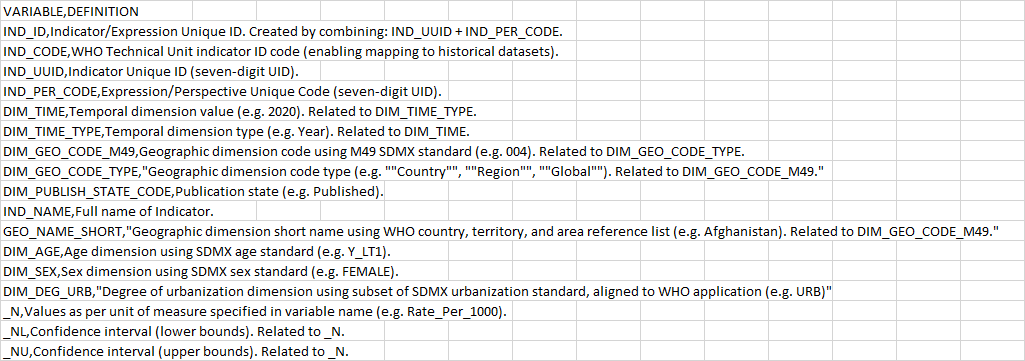

**Lista de Códigos**

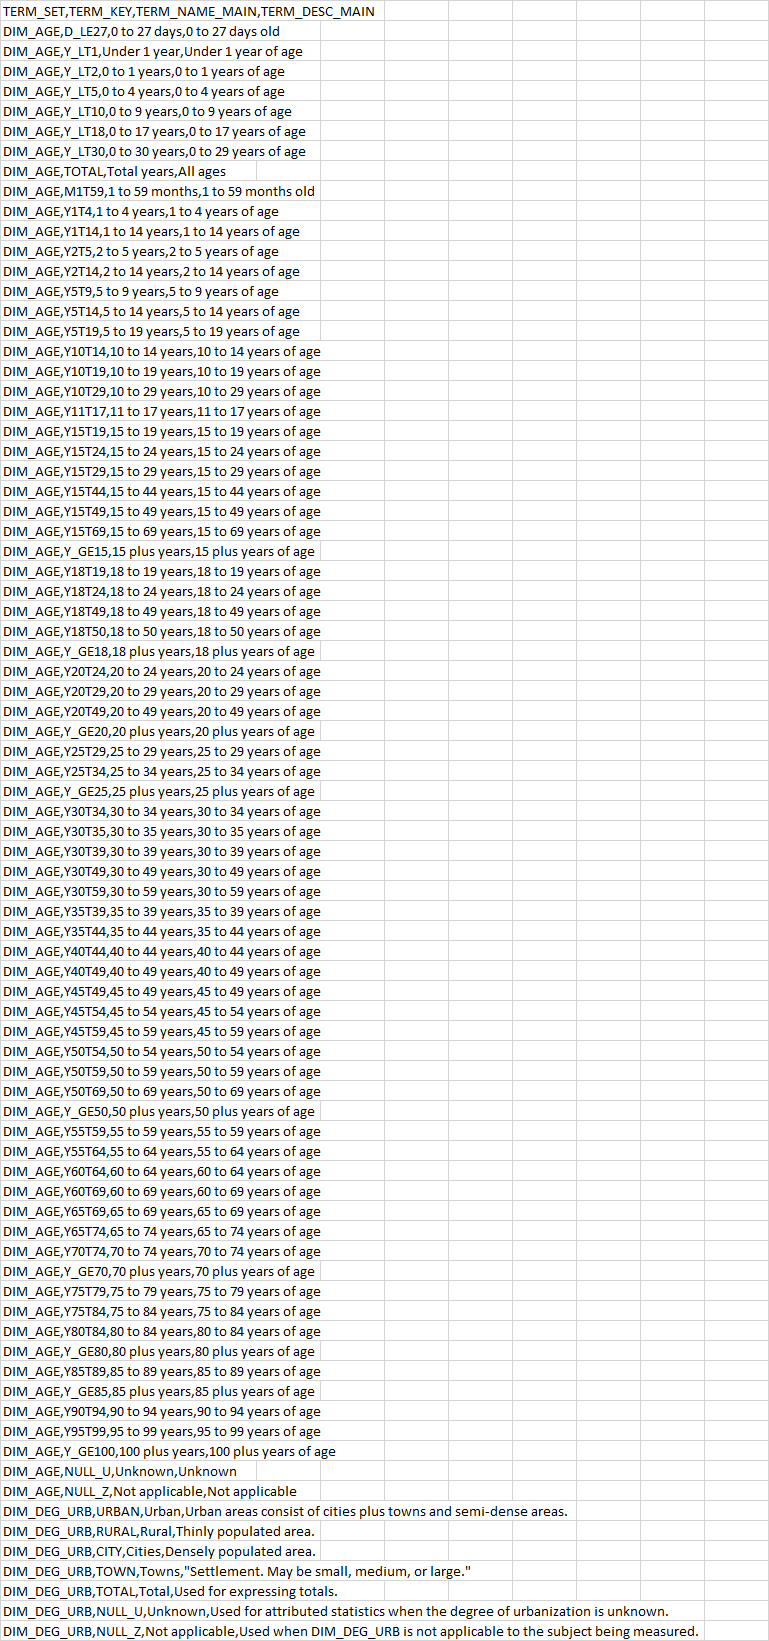

In [10]:
df = pd.read_csv('/content/076_FC5231F_Dataset_2024-03-05.csv', sep=',')
df.head(100)

,IND_UUID,IND_NAME,DIM_GEO_CODE_TYPE,DIM_GEO_CODE_M49,GEO_NAME_SHORT,DIM_TIME_TYPE,DIM_TIME,RATE_PER_100_N,RATE_PER_100_NL,RATE_PER_100_NU
0,FC5231F,Wasting in children (under 5),COUNTRY,76,Brazil,YEAR,2007,1.8,1.3,2.7
1,FC5231F,Wasting in children (under 5),COUNTRY,76,Brazil,YEAR,1989,2.4,1.9,3.2
2,FC5231F,Wasting in children (under 5),COUNTRY,76,Brazil,YEAR,1996,2.8,2.3,3.6
3,FC5231F,Wasting in children (under 5),COUNTRY,76,Brazil,YEAR,2019,3.4,2.9,4.1
4,FC5231F,Wasting in children (under 5),COUNTRY,76,Brazil,YEAR,2007,3.5,2.0,6.1
5,FC5231F,Wasting in children (under 5),COUNTRY,76,Brazil,YEAR,1996,5.4,4.0,7.2
6,FC5231F,Wasting in children (under 5),COUNTRY,76,Brazil,YEAR,2019,5.0,3.8,6.6
7,FC5231F,Wasting in children (under 5),COUNTRY,76,Brazil,YEAR,1989,6.0,4.5,8.0
8,FC5231F,Wasting in children (under 5),COUNTRY,76,Brazil,YEAR,1989,3.7,2.9,4.7
9,FC5231F,Wasting in children (under 5),COUNTRY,76,Brazil,YEAR,2007,3.1,2.0,5.0


In [11]:
#Verificar se os valores são nulos
df.isnull().sum()

,0
IND_UUID,0
IND_NAME,0
DIM_GEO_CODE_TYPE,0
DIM_GEO_CODE_M49,0
GEO_NAME_SHORT,0
DIM_TIME_TYPE,0
DIM_TIME,0
RATE_PER_100_N,0
RATE_PER_100_NL,0
RATE_PER_100_NU,0


In [12]:
#Verificar as informações do CSV
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   IND_UUID           25 non-null     object 
 1   IND_NAME           25 non-null     object 
 2   DIM_GEO_CODE_TYPE  25 non-null     object 
 3   DIM_GEO_CODE_M49   25 non-null     int64  
 4   GEO_NAME_SHORT     25 non-null     object 
 5   DIM_TIME_TYPE      25 non-null     object 
 6   DIM_TIME           25 non-null     int64  
 7   RATE_PER_100_N     25 non-null     float64
 8   RATE_PER_100_NL    25 non-null     float64
 9   RATE_PER_100_NU    25 non-null     float64
dtypes: float64(3), int64(2), object(5)
memory usage: 2.1+ KB


In [13]:
#Verifica os tipos de dados de cada coluna
df.dtypes

,0
IND_UUID,object
IND_NAME,object
DIM_GEO_CODE_TYPE,object
DIM_GEO_CODE_M49,int64
GEO_NAME_SHORT,object
DIM_TIME_TYPE,object
DIM_TIME,int64
RATE_PER_100_N,float64
RATE_PER_100_NL,float64
RATE_PER_100_NU,float64


In [14]:
# Excluindo as colunas desnecessárias IND_UUID até DIM_TIME_TYPE
df = df.drop(columns=['IND_UUID','IND_NAME', 'DIM_GEO_CODE_TYPE', 'DIM_GEO_CODE_M49', 'GEO_NAME_SHORT', 'DIM_TIME_TYPE'])
df.head()

,DIM_TIME,RATE_PER_100_N,RATE_PER_100_NL,RATE_PER_100_NU
0,2007,1.8,1.3,2.7
1,1989,2.4,1.9,3.2
2,1996,2.8,2.3,3.6
3,2019,3.4,2.9,4.1
4,2007,3.5,2.0,6.1


In [15]:
# Ordenando por DIM_TIME para garantir consistência
df = df.sort_values('DIM_TIME')

# Criando projeções futuras (2020-2030)
future_years = np.arange(2020, 2031)
df_historical = df[['DIM_TIME', 'RATE_PER_100_N']].copy()
df_historical['Type'] = 'Histórico'

# Ajustando modelo de regressão linear
X = df_historical['DIM_TIME'].values.reshape(-1, 1)
y = df_historical['RATE_PER_100_N'].values
model = LinearRegression()
model.fit(X, y)

# Projetando para anos futuros
X_future = future_years.reshape(-1, 1)
y_future = model.predict(X_future)

# Criando DataFrame com projeções
df_future = pd.DataFrame({
    'DIM_TIME': future_years,
    'RATE_PER_100_N': y_future,
    'Type': ['Projeção'] * len(future_years)
})

# Concatenando dados históricos e projeções
df_all = pd.concat([df_historical, df_future], ignore_index=True)

# Gráfico 1: Série temporal com dados históricos e projeções
fig1 = go.Figure()

# Dados históricos (linha sólida)
fig1.add_trace(go.Scatter(
    x=df_all[df_all['Type'] == 'Histórico']['DIM_TIME'],
    y=df_all[df_all['Type'] == 'Histórico']['RATE_PER_100_N'],
    mode='lines+markers',
    name='Histórico',
    line=dict(dash='solid', color='blue')
))

# Projeções (linha tracejada)
fig1.add_trace(go.Scatter(
    x=df_all[df_all['Type'] == 'Projeção']['DIM_TIME'],
    y=df_all[df_all['Type'] == 'Projeção']['RATE_PER_100_N'],
    mode='lines+markers',
    name='Projeção',
    line=dict(dash='dash', color='red')
))

fig1.update_layout(
    title='Evolução e Projeção da Taxa de Malnutrição por 100 Pessoas (1989-2030)',
    xaxis_title='Ano',
    yaxis_title='Taxa por 100 Pessoas',
    legend_title='Tipo',
    width=800,
    height=600,
    template='plotly_white'
)
fig1.show()

# Gráfico 2: Dispersão com regressão e projeções
fig2 = px.scatter(
    df_all,
    x='DIM_TIME',
    y='RATE_PER_100_N',
    color='Type',
    title='Dispersão e Projeção da Taxa de Malnutrição por Ano',
    labels={'DIM_TIME': 'Ano', 'RATE_PER_100_N': 'Taxa por 100 Pessoas', 'Type': 'Tipo'},
    hover_data=['DIM_TIME', 'Type'],
    color_discrete_map={'Histórico': 'blue', 'Projeção': 'red'}
)
# Adicionando linha de regressão
X_all = df_all['DIM_TIME'].values.reshape(-1, 1)
y_pred = model.predict(X_all)
fig2.add_trace(go.Scatter(
    x=df_all['DIM_TIME'],
    y=y_pred,
    mode='lines',
    name='Regressão',
    line=dict(dash='dot', color='black')
))

fig2.update_layout(
    width=800,
    height=600,
    xaxis_title='Ano',
    yaxis_title='Taxa por 100 Pessoas',
    legend_title='Tipo',
    template='plotly_white'
)
fig2.show()

# Gráfico 3: Média móvel histórica com projeções
# Calculando média móvel (janela de 3 anos)
df_all['Moving_Avg_N'] = df_all['RATE_PER_100_N'].rolling(window=3, min_periods=1).mean()

fig3 = go.Figure()

# Média móvel histórica
fig3.add_trace(go.Scatter(
    x=df_all[df_all['Type'] == 'Histórico']['DIM_TIME'],
    y=df_all[df_all['Type'] == 'Histórico']['Moving_Avg_N'],
    mode='lines+markers',
    name='Histórico - Média Móvel',
    line=dict(dash='solid', color='blue')
))

# Média móvel projetada
fig3.add_trace(go.Scatter(
    x=df_all[df_all['Type'] == 'Projeção']['DIM_TIME'],
    y=df_all[df_all['Type'] == 'Projeção']['Moving_Avg_N'],
    mode='lines+markers',
    name='Projeção - Média Móvel',
    line=dict(dash='dash', color='red')
))

fig3.update_layout(
    title='Média Móvel (3 anos) da Taxa de Malnutrição com Projeções (1989-2030)',
    xaxis_title='Ano',
    yaxis_title='Média Móvel da Taxa por 100 Pessoas',
    legend_title='Tipo',
    width=800,
    height=600,
    template='plotly_white'
)
fig3.show()

# Estatísticas temporais e projeções
print("\nEstatísticas temporais e projeções:")
df_historical = df_all[df_all['Type'] == 'Histórico']
df_projected = df_all[df_all['Type'] == 'Projeção']
slope = model.coef_[0]
print(f"Média histórica (1989-2019): {df_historical['RATE_PER_100_N'].mean():.2f}")
print(f"Inclinação temporal (tendência): {slope:.4f} por ano")
print(f"Projeção para 2030: {df_projected[df_projected['DIM_TIME'] == 2030]['RATE_PER_100_N'].values[0]:.2f}")


Estatísticas temporais e projeções:
Média histórica (1989-2019): 3.76
Inclinação temporal (tendência): 0.0112 por ano
Projeção para 2030: 4.07


### **Água potável gerenciada com segurança projetada até 2030**

Dataset Safely Managed Drinking Water

In [16]:
#bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

**Dicionário do CSV Safely Managed Drinking Water**

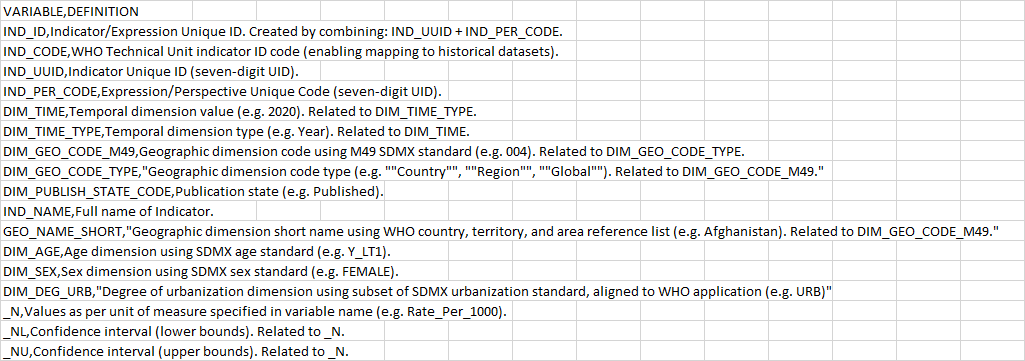

**Lista de Códigos**

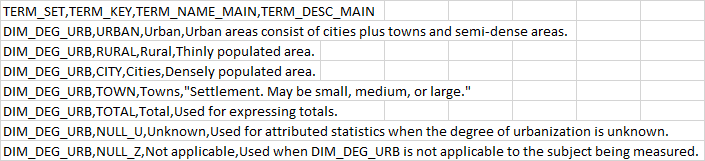


In [17]:
df = pd.read_csv('/content/076_1548EA3_Dataset_2024-01-08.csv', sep=',')
df.head()

,IND_UUID,IND_NAME,DIM_GEO_CODE_TYPE,DIM_GEO_CODE_M49,GEO_NAME_SHORT,DIM_TIME_TYPE,DIM_TIME,Degree of urbanization,PERCENT_POP_N
0,1548EA3,Population using safely managed drinking-water...,COUNTRY,76,Brazil,YEAR,2000,Rural,46.97544
1,1548EA3,Population using safely managed drinking-water...,COUNTRY,76,Brazil,YEAR,2001,Rural,49.05126
2,1548EA3,Population using safely managed drinking-water...,COUNTRY,76,Brazil,YEAR,2007,Rural,53.71782
3,1548EA3,Population using safely managed drinking-water...,COUNTRY,76,Brazil,YEAR,2008,Rural,54.40484
4,1548EA3,Population using safely managed drinking-water...,COUNTRY,76,Brazil,YEAR,2010,Rural,55.77887


In [18]:
#Verificar se os valores são nulos
df.isnull().sum()

,0
IND_UUID,0
IND_NAME,0
DIM_GEO_CODE_TYPE,0
DIM_GEO_CODE_M49,0
GEO_NAME_SHORT,0
DIM_TIME_TYPE,0
DIM_TIME,0
Degree of urbanization,0
PERCENT_POP_N,0


In [19]:
#Verificar as informações do CSV
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IND_UUID                46 non-null     object 
 1   IND_NAME                46 non-null     object 
 2   DIM_GEO_CODE_TYPE       46 non-null     object 
 3   DIM_GEO_CODE_M49        46 non-null     int64  
 4   GEO_NAME_SHORT          46 non-null     object 
 5   DIM_TIME_TYPE           46 non-null     object 
 6   DIM_TIME                46 non-null     int64  
 7   Degree of urbanization  46 non-null     object 
 8   PERCENT_POP_N           46 non-null     float64
dtypes: float64(1), int64(2), object(6)
memory usage: 3.4+ KB


In [20]:
#Verifica os tipos de dados de cada coluna
df.dtypes

,0
IND_UUID,object
IND_NAME,object
DIM_GEO_CODE_TYPE,object
DIM_GEO_CODE_M49,int64
GEO_NAME_SHORT,object
DIM_TIME_TYPE,object
DIM_TIME,int64
Degree of urbanization,object
PERCENT_POP_N,float64


In [21]:
# Excluindo as colunas desnecessárias IND_UUID até DIM_TIME_TYPE
df = df.drop(columns=['IND_UUID','IND_NAME', 'DIM_GEO_CODE_TYPE', 'DIM_GEO_CODE_M49', 'GEO_NAME_SHORT', 'DIM_TIME_TYPE'])
df.head()

,DIM_TIME,Degree of urbanization,PERCENT_POP_N
0,2000,Rural,46.97544
1,2001,Rural,49.05126
2,2007,Rural,53.71782
3,2008,Rural,54.40484
4,2010,Rural,55.77887


In [22]:
#Transformar a coluna Grau de urbanização em 0 e 1
df['Degree of urbanization'] = df['Degree of urbanization'].map({'Rural': 0, 'Total': 1})
df.head()

,DIM_TIME,Degree of urbanization,PERCENT_POP_N
0,2000,0,46.97544
1,2001,0,49.05126
2,2007,0,53.71782
3,2008,0,54.40484
4,2010,0,55.77887


In [23]:
# Mapeando Degree of urbanization para Rural e Total
df['Degree of urbanization'] = df['Degree of urbanization'].map({0: 'Rural', 1: 'Total'})

# Ordenando por DIM_TIME para garantir consistência
df = df.sort_values(['Degree of urbanization', 'DIM_TIME'])

# Criando projeções futuras (2023-2030)
future_years = np.arange(2023, 2031)
projections = []

# Ajustando modelo de regressão linear para cada nível de urbanização
for urbanization in df['Degree of urbanization'].unique():
    df_urb = df[df['Degree of urbanization'] == urbanization]

    # Preparando dados para regressão
    X = df_urb['DIM_TIME'].values.reshape(-1, 1)
    y = df_urb['PERCENT_POP_N'].values

    # Treinando o modelo
    model = LinearRegression()
    model.fit(X, y)

    # Projetando para anos futuros
    X_future = future_years.reshape(-1, 1)
    y_future = model.predict(X_future)

    # Criando DataFrame com projeções
    df_future = pd.DataFrame({
        'DIM_TIME': future_years,
        'Degree of urbanization': [urbanization] * len(future_years),
        'PERCENT_POP_N': y_future,
        'Type': ['Projeção'] * len(future_years)
    })

    # Adicionando dados históricos
    df_historical = df_urb[['DIM_TIME', 'Degree of urbanization', 'PERCENT_POP_N']].copy()
    df_historical['Type'] = 'Histórico'

    # Concatenando dados históricos e projeções
    projections.append(pd.concat([df_historical, df_future], ignore_index=True))

# Combinando todas as projeções
df_all = pd.concat(projections, ignore_index=True)

# Gráfico 1: Série temporal com dados históricos e projeções
fig1 = go.Figure()

for urbanization in df_all['Degree of urbanization'].unique():
    df_urb = df_all[df_all['Degree of urbanization'] == urbanization]

    # Dados históricos (linha sólida)
    fig1.add_trace(go.Scatter(
        x=df_urb[df_urb['Type'] == 'Histórico']['DIM_TIME'],
        y=df_urb[df_urb['Type'] == 'Histórico']['PERCENT_POP_N'],
        mode='lines+markers',
        name=f'{urbanization} (Histórico)',
        line=dict(dash='solid')
    ))

    # Projeções (linha tracejada)
    fig1.add_trace(go.Scatter(
        x=df_urb[df_urb['Type'] == 'Projeção']['DIM_TIME'],
        y=df_urb[df_urb['Type'] == 'Projeção']['PERCENT_POP_N'],
        mode='lines+markers',
        name=f'{urbanization} (Projeção)',
        line=dict(dash='dash')
    ))

fig1.update_layout(
    title='Evolução e Projeção do Acesso a Água Potável Segura por Urbanização (2000-2030)',
    xaxis_title='Ano',
    yaxis_title='Porcentagem da População (%)',
    legend_title='Urbanização e Tipo',
    width=800,
    height=600,
    template='plotly_white'
)
fig1.show()

# Gráfico 2: Dispersão com regressão e projeções
fig2 = px.scatter(
    df_all,
    x='DIM_TIME',
    y='PERCENT_POP_N',
    color='Degree of urbanization',
    symbol='Type',
    title='Dispersão e Projeção do Acesso a Água Potável Segura por Ano',
    labels={'DIM_TIME': 'Ano', 'PERCENT_POP_N': 'Porcentagem da População (%)', 'Degree of urbanization': 'Urbanização'},
    hover_data=['DIM_TIME', 'Degree of urbanization', 'Type'],
    color_discrete_map={'Rural': 'blue', 'Total': 'red'}
)
# Adicionando linhas de regressão
for urbanization in df_all['Degree of urbanization'].unique():
    df_urb = df_all[df_all['Degree of urbanization'] == urbanization]
    model = LinearRegression()
    X = df_urb[df_urb['Type'] == 'Histórico']['DIM_TIME'].values.reshape(-1, 1)
    y = df_urb[df_urb['Type'] == 'Histórico']['PERCENT_POP_N'].values
    model.fit(X, y)
    X_all = df_urb['DIM_TIME'].values.reshape(-1, 1)
    y_pred = model.predict(X_all)
    fig2.add_trace(go.Scatter(
        x=df_urb['DIM_TIME'],
        y=y_pred,
        mode='lines',
        name=f'Regressão {urbanization}',
        line=dict(dash='dot')
    ))

fig2.update_layout(
    width=800,
    height=600,
    xaxis_title='Ano',
    yaxis_title='Porcentagem da População (%)',
    legend_title='Urbanização e Tipo',
    template='plotly_white'
)
fig2.show()

# Gráfico 3: Média móvel histórica com projeções
# Calculando média móvel (janela de 3 anos)
df_all['Moving_Avg_N'] = df_all.groupby('Degree of urbanization')['PERCENT_POP_N'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

fig3 = go.Figure()

for urbanization in df_all['Degree of urbanization'].unique():
    df_urb = df_all[df_all['Degree of urbanization'] == urbanization]

    # Média móvel histórica
    fig3.add_trace(go.Scatter(
        x=df_urb[df_urb['Type'] == 'Histórico']['DIM_TIME'],
        y=df_urb[df_urb['Type'] == 'Histórico']['Moving_Avg_N'],
        mode='lines+markers',
        name=f'{urbanization} (Histórico - Média Móvel)',
        line=dict(dash='solid')
    ))

    # Média móvel projetada
    fig3.add_trace(go.Scatter(
        x=df_urb[df_urb['Type'] == 'Projeção']['DIM_TIME'],
        y=df_urb[df_urb['Type'] == 'Projeção']['Moving_Avg_N'],
        mode='lines+markers',
        name=f'{urbanization} (Projeção - Média Móvel)',
        line=dict(dash='dash')
    ))

fig3.update_layout(
    title='Média Móvel (3 anos) do Acesso a Água Potável Segura com Projeções (2000-2030)',
    xaxis_title='Ano',
    yaxis_title='Média Móvel da Porcentagem da População (%)',
    legend_title='Urbanização e Tipo',
    width=800,
    height=600,
    template='plotly_white'
)
fig3.show()

# Estatísticas temporais e projeções
print("\nEstatísticas temporais e projeções por urbanização:")
for urbanization in df_all['Degree of urbanization'].unique():
    df_urb = df_all[df_all['Degree of urbanization'] == urbanization]
    df_historical = df_urb[df_urb['Type'] == 'Histórico']
    df_projected = df_urb[df_urb['Type'] == 'Projeção']

    # Inclinação da regressão
    model = LinearRegression()
    X = df_historical['DIM_TIME'].values.reshape(-1, 1)
    y = df_historical['PERCENT_POP_N'].values
    model.fit(X, y)
    slope = model.coef_[0]

    print(f"Urbanização {urbanization}:")
    print(f"  Média histórica (2000-2022): {df_historical['PERCENT_POP_N'].mean():.2f}%")
    print(f"  Inclinação temporal (tendência): {slope:.4f}% por ano")
    print(f"  Projeção para 2030: {df_projected[df_projected['DIM_TIME'] == 2030]['PERCENT_POP_N'].values[0]:.2f}%")


Estatísticas temporais e projeções por urbanização:
Urbanização Rural:
  Média histórica (2000-2022): 59.27%
  Inclinação temporal (tendência): 1.2462% por ano
  Projeção para 2030: 82.95%
Urbanização Total:
  Média histórica (2000-2022): 80.58%
  Inclinação temporal (tendência): 0.4940% por ano
  Projeção para 2030: 89.97%
